In [31]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/senaca/mimii-pump-sound-dataset/normal/00000291.wav
/kaggle/input/datasets/senaca/mimii-pump-sound-dataset/normal/00000216.wav
/kaggle/input/datasets/senaca/mimii-pump-sound-dataset/normal/00000038.wav
/kaggle/input/datasets/senaca/mimii-pump-sound-dataset/normal/00000229.wav
/kaggle/input/datasets/senaca/mimii-pump-sound-dataset/normal/00000034.wav
/kaggle/input/datasets/senaca/mimii-pump-sound-dataset/normal/00000255.wav
/kaggle/input/datasets/senaca/mimii-pump-sound-dataset/normal/00000002.wav
/kaggle/input/datasets/senaca/mimii-pump-sound-dataset/normal/00000083.wav
/kaggle/input/datasets/senaca/mimii-pump-sound-dataset/normal/00000380.wav
/kaggle/input/datasets/senaca/mimii-pump-sound-dataset/normal/00000223.wav
/kaggle/input/datasets/senaca/mimii-pump-sound-dataset/normal/00000328.wav
/kaggle/input/datasets/senaca/mimii-pump-sound-dataset/normal/00000148.wav
/kaggle/input/datasets/senaca/mimii-pump-sound-dataset/normal/00000323.wav
/kaggle/input/datasets/se

In [32]:
# If running outside Kaggle (e.g. Colab / local), uncomment to install deps.
# !pip install -q librosa soundfile torch torchvision scikit-learn tqdm matplotlib seaborn kagglehub

import os, glob, json, random, warnings, math, time
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, roc_curve, precision_recall_fscore_support,
                              confusion_matrix, precision_recall_curve)
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cpu


In [33]:

import os
import glob

CANDIDATE_ROOTS = glob.glob(
    "/kaggle/input/**/mimii-pump-sound-dataset",
    recursive=True
)

DATASET_ROOT = None

for c in CANDIDATE_ROOTS:
    if os.path.isdir(c):
        DATASET_ROOT = c
        break

if DATASET_ROOT is None:
    DATASET_ROOT = "./mimii-pump-sound-dataset"

print("Using dataset root:", DATASET_ROOT)


all_wavs = glob.glob(
    os.path.join(DATASET_ROOT, "**", "*.wav"),
    recursive=True
)

print(f"Found {len(all_wavs)} wav files")

assert len(all_wavs) > 0, \
    "No wav files found — check DATASET_ROOT / dataset attachment."

print(all_wavs[0])

Using dataset root: /kaggle/input/datasets/senaca/mimii-pump-sound-dataset
Found 519 wav files
/kaggle/input/datasets/senaca/mimii-pump-sound-dataset/normal/00000291.wav


In [34]:
import re

def parse_wav_path(path):
    """Extract (machine_type, machine_id, label) from a MIMII-style path.
    Regex-based on the FULL lowercased path (not just exact folder-name matches), so it survives
    naming variants like 'Abnormal', 'id-00', 'pump_id_00', or labels embedded in the filename.
    """
    low = path.lower()

    label = None
    if re.search(r'(?<![a-z])abnormal(?![a-z])', low):
        label = "abnormal"
    elif re.search(r'(?<![a-z])normal(?![a-z])', low):
        label = "normal"

    machine_id = None
    m = re.search(r'id[_\-]?(\d+)', low)
    if m:
        machine_id = f"id_{m.group(1)}"

    machine_type = None
    for cand in ["pump", "fan", "valve", "slider"]:
        if cand in low:
            machine_type = cand
            break
    if machine_type is None:
        machine_type = "pump"  # this dataset is pump-only

    # if no explicit id_XX is present, this dataset likely has a single unit —
    # pool everything under the machine_type instead of dropping the file entirely
    if machine_id is None:
        machine_id = machine_type

    return machine_type, machine_id, label

records = []
unlabeled_examples = []
for w in all_wavs:
    mtype, mid, label = parse_wav_path(w)
    if label is None:
        if len(unlabeled_examples) < 5:
            unlabeled_examples.append(w)
        continue
    records.append({"path": w, "machine_type": mtype, "machine_id": mid, "label": label})

print(f"Parsed {len(records)} / {len(all_wavs)} files successfully.")

if len(records) == 0:
    # Don't let this fail with a cryptic KeyError — show exactly what we're looking at instead.
    print("\nCouldn't detect normal/abnormal from ANY path. Sample paths for inspection:")
    for w in all_wavs[:10]:
        print(" ", w)
    print("\nUnique path components seen (first 40):")
    from collections import Counter
    token_counts = Counter()
    for w in all_wavs[:2000]:
        token_counts.update(Path(w).parts)
    for tok, cnt in token_counts.most_common(40):
        print(f"   {tok!r}: {cnt}")
    raise RuntimeError(
        "No files could be labeled normal/abnormal. Inspect the sample paths and token counts "
        "printed above, then adjust parse_wav_path()'s label detection to match this dataset's "
        "actual naming convention (e.g. it may use 'OK'/'NG', a CSV of labels instead of folder "
        "names, or a different word for anomalous clips)."
    )

if unlabeled_examples:
    print(f"\n{len(all_wavs) - len(records)} files had no normal/abnormal label and were skipped, e.g.:")
    for w in unlabeled_examples:
        print(" ", w)

df = pd.DataFrame(records)
print()
print(df.groupby(["machine_type", "machine_id", "label"]).size())
df.head()


Parsed 519 / 519 files successfully.

machine_type  machine_id  label   
pump          pump        abnormal    138
                          normal      381
dtype: int64


,path,machine_type,machine_id,label
0,/kaggle/input/datasets/senaca/mimii-pump-sound...,pump,pump,normal
1,/kaggle/input/datasets/senaca/mimii-pump-sound...,pump,pump,normal
2,/kaggle/input/datasets/senaca/mimii-pump-sound...,pump,pump,normal
3,/kaggle/input/datasets/senaca/mimii-pump-sound...,pump,pump,normal
4,/kaggle/input/datasets/senaca/mimii-pump-sound...,pump,pump,normal


log-mel shape: (128, 313)


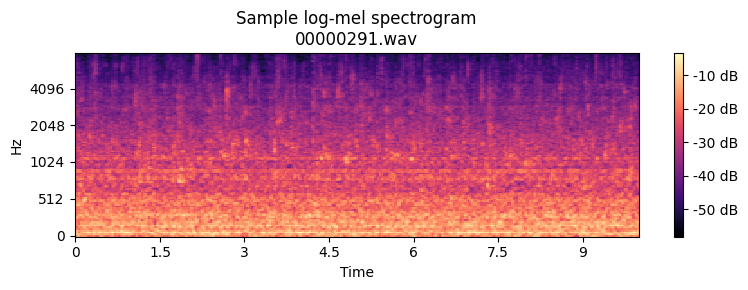

In [35]:
PREPROC_CONFIG = {
    "sample_rate": 16000,
    "n_fft": 2048,          # increased from 1024 for finer frequency resolution
    "hop_length": 512,
    "n_mels": 128,          # increased from 64 — pumps have relevant detail above the coarse 64-bin grid
    "fmin": 0,
    "fmax": 8000,
    "power": 2.0,
    "top_db": 80.0,
    "fixed_frames": 313,   # ~10s clip at sr=16000, hop=512  ->  (10*16000)/512 ≈ 312.5 (unaffected by n_fft/n_mels)
    "clip_duration_sec": 10.0,
    "trim_silence": True,   # trim leading/trailing near-silence before mel extraction
    # normalization stats — computed from the TRAIN split of NORMAL audio only (Section 3)
    "norm_mean": None,
    "norm_std": None,
}

def wav_to_logmel(path, cfg=PREPROC_CONFIG):
    y, sr = librosa.load(path, sr=cfg["sample_rate"], mono=True)
    if cfg.get("trim_silence", False):
        y, _ = librosa.effects.trim(y, top_db=30)
    target_len = int(cfg["clip_duration_sec"] * cfg["sample_rate"])
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    else:
        y = y[:target_len]

    mel = librosa.feature.melspectrogram(
        y=y, sr=cfg["sample_rate"], n_fft=cfg["n_fft"], hop_length=cfg["hop_length"],
        n_mels=cfg["n_mels"], fmin=cfg["fmin"], fmax=cfg["fmax"], power=cfg["power"]
    )
    logmel = librosa.power_to_db(mel, top_db=cfg["top_db"])

    # pad/truncate time axis to fixed_frames
    T = cfg["fixed_frames"]
    if logmel.shape[1] < T:
        logmel = np.pad(logmel, ((0, 0), (0, T - logmel.shape[1])), mode="edge")
    else:
        logmel = logmel[:, :T]
    return logmel.astype(np.float32)  # shape (n_mels, T)

# quick sanity check + visualization
sample_path = df.iloc[0]["path"]
sample_logmel = wav_to_logmel(sample_path)
print("log-mel shape:", sample_logmel.shape)

plt.figure(figsize=(8, 3))
librosa.display.specshow(sample_logmel, sr=PREPROC_CONFIG["sample_rate"],
                          hop_length=PREPROC_CONFIG["hop_length"], x_axis="time", y_axis="mel")
plt.colorbar(format="%+2.0f dB")
plt.title(f"Sample log-mel spectrogram\n{Path(sample_path).name}")
plt.tight_layout()
plt.show()


In [36]:
def make_splits(df_machine, val_frac=0.15, test_normal_frac=0.15,
                 thresh_normal_frac=0.15, thresh_abnormal_frac=0.30, seed=SEED):
    normal = df_machine[df_machine.label == "normal"].sample(frac=1, random_state=seed).reset_index(drop=True)
    abnormal = df_machine[df_machine.label == "abnormal"].sample(frac=1, random_state=seed).reset_index(drop=True)

    n = len(normal)
    n_val = int(n * val_frac)
    n_test_normal = int(n * test_normal_frac)
    n_thresh_normal = int(n * thresh_normal_frac)

    val_df = normal.iloc[:n_val]
    test_normal_df = normal.iloc[n_val:n_val + n_test_normal]
    thresh_normal_df = normal.iloc[n_val + n_test_normal:n_val + n_test_normal + n_thresh_normal]
    train_df = normal.iloc[n_val + n_test_normal + n_thresh_normal:]

    n_ab = len(abnormal)
    n_thresh_ab = max(1, int(n_ab * thresh_abnormal_frac)) if n_ab > 0 else 0
    thresh_abnormal_df = abnormal.iloc[:n_thresh_ab]
    test_abnormal_df = abnormal.iloc[n_thresh_ab:]

    thresh_df = pd.concat([thresh_normal_df, thresh_abnormal_df], ignore_index=True)
    test_df = pd.concat([test_normal_df, test_abnormal_df], ignore_index=True)
    return (train_df.reset_index(drop=True), val_df.reset_index(drop=True),
            thresh_df.reset_index(drop=True), test_df.reset_index(drop=True))

SPLITS = {}
for mid, g in df.groupby("machine_id"):
    SPLITS[mid] = make_splits(g)
    tr, va, th, te = SPLITS[mid]
    print(f"{mid}: train(normal)={len(tr)}  val(normal)={len(va)}  "
          f"thresh-tune={len(th)} (normal={sum(th.label=='normal')}, abnormal={sum(th.label=='abnormal')})  "
          f"test={len(te)} (normal={sum(te.label=='normal')}, abnormal={sum(te.label=='abnormal')})")


pump: train(normal)=210  val(normal)=57  thresh-tune=98 (normal=57, abnormal=41)  test=154 (normal=57, abnormal=97)


In [37]:
class MelDataset(Dataset):
    def __init__(self, dataframe, cfg=PREPROC_CONFIG, mean=None, std=None, cache=True):
        self.df = dataframe.reset_index(drop=True)
        self.cfg = cfg
        self.mean = mean
        self.std = std
        self.cache = {}
        self.use_cache = cache

    def __len__(self):
        return len(self.df)

    def _get_logmel(self, idx):
        if self.use_cache and idx in self.cache:
            return self.cache[idx]
        path = self.df.iloc[idx]["path"]
        logmel = wav_to_logmel(path, self.cfg)
        if self.use_cache:
            self.cache[idx] = logmel
        return logmel

    def __getitem__(self, idx):
        logmel = self._get_logmel(idx)
        if self.mean is not None and self.std is not None:
            logmel = (logmel - self.mean) / (self.std + 1e-8)
        row = self.df.iloc[idx]
        label = 1 if row["label"] == "abnormal" else 0  # 1 = anomaly, for eval only
        x = torch.from_numpy(logmel).unsqueeze(0)  # (1, n_mels, T)
        return x, label, row["path"]

def compute_norm_stats(train_df, cfg=PREPROC_CONFIG, max_samples=300):
    """Mean/std over the TRAIN (normal-only) split — this is what ships in the artifact."""
    sample_paths = train_df["path"].sample(
        n=min(max_samples, len(train_df)), random_state=SEED
    )
    mels = [wav_to_logmel(p, cfg) for p in tqdm(sample_paths, desc="computing norm stats")]
    stacked = np.stack(mels)
    return float(stacked.mean()), float(stacked.std())


In [38]:
class ConvAutoencoderV1(nn.Module):
    """Compact baseline: 3-layer conv encoder/decoder."""
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1), nn.BatchNorm2d(16), nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1), nn.BatchNorm2d(16), nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1),
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        out = F.interpolate(out, size=x.shape[-2:], mode="bilinear", align_corners=False)
        return out


class ConvAutoencoderV2(nn.Module):
    """Deeper autoencoder with a bottleneck FC layer — more capacity, stronger regularization via dropout."""
    def __init__(self, n_mels=64, fixed_frames=313, latent_dim=64):
        super().__init__()
        self.enc_conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1), nn.BatchNorm2d(16), nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Dropout(0.2),
        )
        with torch.no_grad():
            dummy = torch.zeros(1, 1, n_mels, fixed_frames)
            enc_out = self.enc_conv(dummy)
            self._enc_shape = enc_out.shape[1:]
            flat_dim = int(np.prod(self._enc_shape))

        self.fc_enc = nn.Linear(flat_dim, latent_dim)
        self.fc_dec = nn.Linear(latent_dim, flat_dim)

        self.dec_conv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1), nn.BatchNorm2d(16), nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1),
        )

    def forward(self, x):
        z = self.enc_conv(x)
        b = z.shape[0]
        z_flat = z.reshape(b, -1)
        latent = self.fc_enc(z_flat)
        z_rec = self.fc_dec(latent).reshape(b, *self._enc_shape)
        out = self.dec_conv(z_rec)
        out = F.interpolate(out, size=x.shape[-2:], mode="bilinear", align_corners=False)
        return out


MODEL_REGISTRY = {
    "conv_ae_v1": ConvAutoencoderV1,
    "conv_ae_v2": lambda: ConvAutoencoderV2(n_mels=PREPROC_CONFIG["n_mels"], fixed_frames=PREPROC_CONFIG["fixed_frames"]),
}


In [39]:
def train_autoencoder(model, train_loader, val_loader, epochs=30, lr=1e-3, patience=5, verbose=True):
    model = model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=2)

    best_val = float("inf")
    best_state = None
    epochs_no_improve = 0
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(epochs):
        model.train()
        train_losses = []
        for x, _, _ in train_loader:
            x = x.to(DEVICE)
            opt.zero_grad()
            recon = model(x)
            loss = F.mse_loss(recon, x)
            loss.backward()
            opt.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for x, _, _ in val_loader:
                x = x.to(DEVICE)
                recon = model(x)
                loss = F.mse_loss(recon, x)
                val_losses.append(loss.item())

        tr_loss, va_loss = np.mean(train_losses), np.mean(val_losses)
        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        sched.step(va_loss)

        if verbose:
            print(f"  epoch {epoch+1:02d}/{epochs}  train_loss={tr_loss:.5f}  val_loss={va_loss:.5f}")

        if va_loss < best_val - 1e-5:
            best_val = va_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                if verbose:
                    print(f"  early stopping at epoch {epoch+1}")
                break

    model.load_state_dict(best_state)
    return model, history, best_val


In [40]:
def reconstruction_errors(model, loader):
    model.eval()
    errors, labels, paths = [], [], []
    with torch.no_grad():
        for x, y, p in loader:
            x = x.to(DEVICE)
            recon = model(x)
            per_sample_mse = F.mse_loss(recon, x, reduction="none").mean(dim=[1, 2, 3])
            errors.extend(per_sample_mse.cpu().numpy().tolist())
            labels.extend(y.numpy().tolist() if torch.is_tensor(y) else list(y))
            paths.extend(p)
    return np.array(errors), np.array(labels), paths

def evaluate_at_threshold(errors, labels, threshold):
    preds = (errors >= threshold).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary", zero_division=0
    )
    cm = confusion_matrix(labels, preds, labels=[0, 1])
    return {"precision": precision, "recall": recall, "f1": f1, "confusion_matrix": cm.tolist()}

THRESH_BETA = 0.85  # <1 weights precision over recall; pulled back from 0.7 now that soft-voting
                     # already raised AUC substantially — less aggressive threshold bias needed to
                     # hit good precision, which leaves more room for recall.

def optimize_threshold_f1(errors, labels, beta=THRESH_BETA):
    """Sweep every candidate cutoff (each observed error value) and return the threshold
    that maximizes F-beta on the given (thresh-tuning) set. beta<1 weights precision more than
    recall — use this (instead of plain F1, beta=1) when precision is too low for comfort.
    Falls back to the 95th percentile of normal-only errors if no abnormal examples are present.
    """
    if (labels == 1).sum() == 0:
        return float(np.percentile(errors[labels == 0], 95))
    precisions, recalls, thresholds = precision_recall_curve(labels, errors)
    b2 = beta ** 2
    fbeta = (1 + b2) * precisions * recalls / (b2 * precisions + recalls + 1e-12)
    # precision_recall_curve returns thresholds of len(N-1); align with fbeta[:-1]
    best_idx = int(np.nanargmax(fbeta[:-1])) if len(thresholds) > 0 else 0
    return float(thresholds[best_idx]) if len(thresholds) > 0 else float(np.percentile(errors, 95))


In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_predict

def extract_features(model, loader):
    """Per-clip features: mean / max / std / p90 of the per-time-frame reconstruction error."""
    model.eval()
    feats, labels, paths = [], [], []
    with torch.no_grad():
        for x, y, p in loader:
            x = x.to(DEVICE)
            recon = model(x)
            err = (recon - x) ** 2                       # (B, 1, n_mels, T)
            frame_err = err.mean(dim=2).squeeze(1)         # (B, T) — avg over mel bins per frame
            mean_err = frame_err.mean(dim=1)
            max_err = frame_err.max(dim=1).values
            std_err = frame_err.std(dim=1)
            p90_err = torch.quantile(frame_err, 0.90, dim=1)
            batch_feats = torch.stack([mean_err, max_err, std_err, p90_err], dim=1).cpu().numpy()
            feats.append(batch_feats)
            labels.extend(y.numpy().tolist() if torch.is_tensor(y) else list(y))
            paths.extend(p)
    return np.concatenate(feats, axis=0), np.array(labels), paths

CANDIDATE_CLASSIFIERS = {
    "logreg": lambda: LogisticRegression(max_iter=2000, C=1.0),
    "random_forest": lambda: RandomForestClassifier(
        n_estimators=200, max_depth=4, min_samples_leaf=3, random_state=SEED
    ),
    "gradient_boosting": lambda: GradientBoostingClassifier(
        n_estimators=150, max_depth=2, learning_rate=0.05, random_state=SEED
    ),
}

def train_supervised_combiner(feat_list_thresh, labels_thresh):
    """feat_list_thresh: list of per-model feature arrays (each N x 4) on the thresh-tuning split,
    concatenated column-wise. Fits ALL candidate classifiers and combines them with AUC-weighted soft
    voting: each classifier's internal 3-fold CV AUC (on the thresh-tuning split) sets its vote weight,
    so a genuinely stronger classifier contributes more than a weak one instead of every vote counting
    equally. Falls back to uniform weights if there's too little data for a stable internal CV. Also
    drops class_weight='balanced' — it was pushing the boundary toward recall at precision's expense."""
    X = np.concatenate(feat_list_thresh, axis=1)
    scaler = StandardScaler().fit(X)
    Xs = scaler.transform(X)

    n_pos = int((labels_thresh == 1).sum())
    weights = {}
    if n_pos >= 4:
        n_splits = min(3, n_pos)
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
        for name, ctor in CANDIDATE_CLASSIFIERS.items():
            try:
                probs = cross_val_predict(ctor(), Xs, labels_thresh, cv=skf, method="predict_proba")[:, 1]
                weights[name] = max(roc_auc_score(labels_thresh, probs), 0.5) - 0.5  # 0 floor for <=chance
            except Exception:
                weights[name] = 0.0
    if not weights or sum(weights.values()) < 1e-6:
        weights = {name: 1.0 for name in CANDIDATE_CLASSIFIERS}  # fallback: uniform
    total_w = sum(weights.values())
    weights = {name: w / total_w for name, w in weights.items()}

    fitted = {}
    for name, ctor in CANDIDATE_CLASSIFIERS.items():
        clf = ctor()
        clf.fit(Xs, labels_thresh)
        fitted[name] = clf

    def score_fn(feat_list):
        Xq = scaler.transform(np.concatenate(feat_list, axis=1))
        probs = sum(weights[name] * clf.predict_proba(Xq)[:, 1] for name, clf in fitted.items())
        return probs

    combiner_name = "auc_weighted_vote(" + ", ".join(f"{k}={v:.2f}" for k, v in weights.items()) + ")"
    return fitted, scaler, score_fn, combiner_name, weights


In [ ]:
BATCH_SIZE = 16
EPOCHS = 40
N_FOLDS = 5
FOLD_SEEDS = [42, 123, 2024, 7, 99][:N_FOLDS]

def run_one_fold(df_machine, seed):
    train_df, val_df, thresh_df, test_df = make_splits(df_machine, seed=seed, thresh_abnormal_frac=0.45)
    if len(train_df) < 10 or len(test_df[test_df.label == "abnormal"]) < 2 \
            or len(thresh_df[thresh_df.label == "abnormal"]) < 2:
        return None

    mean, std = compute_norm_stats(train_df)

    train_ds = MelDataset(train_df, mean=mean, std=std)
    val_ds = MelDataset(val_df, mean=mean, std=std)
    thresh_ds = MelDataset(thresh_df, mean=mean, std=std)
    test_ds = MelDataset(test_df, mean=mean, std=std)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    thresh_loader = DataLoader(thresh_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    arch_models, arch_scores = {}, {}
    feat_thresh, feat_test = {}, {}
    thresh_lab_ref, test_lab_ref = None, None

    for arch_name, arch_ctor in MODEL_REGISTRY.items():
        model = arch_ctor()
        model, _, _ = train_autoencoder(model, train_loader, val_loader, epochs=EPOCHS, verbose=False)
        arch_models[arch_name] = model

        th_err, th_lab, _ = reconstruction_errors(model, thresh_loader)
        te_err, te_lab, _ = reconstruction_errors(model, test_loader)
        arch_scores[arch_name] = (th_err, th_lab, te_err, te_lab)
        thresh_lab_ref, test_lab_ref = th_lab, te_lab

        feat_thresh[arch_name], _, _ = extract_features(model, thresh_loader)
        feat_test[arch_name], _, _ = extract_features(model, test_loader)

    names = list(arch_models.keys())
    a0, a1 = names[0], names[1]
    th_err0 = arch_scores[a0][0]; te_err0 = arch_scores[a0][2]
    th_err1 = arch_scores[a1][0]; te_err1 = arch_scores[a1][2]
    m0, s0 = th_err0.mean(), th_err0.std() + 1e-8
    m1, s1 = th_err1.mean(), th_err1.std() + 1e-8
    ens_th = 0.5 * ((th_err0 - m0) / s0) + 0.5 * ((th_err1 - m1) / s1)
    ens_te = 0.5 * ((te_err0 - m0) / s0) + 0.5 * ((te_err1 - m1) / s1)
    arch_scores["ensemble"] = (ens_th, thresh_lab_ref, ens_te, test_lab_ref)

    clf, scaler, score_fn, combiner_name, combiner_weights = train_supervised_combiner(
        [feat_thresh[a] for a in names], thresh_lab_ref
    )
    combo_th = score_fn([feat_thresh[a] for a in names])
    combo_te = score_fn([feat_test[a] for a in names])
    arch_scores["supervised_combo"] = (combo_th, thresh_lab_ref, combo_te, test_lab_ref)

    fold_result = {}
    for arch_name, (th_s, th_l, te_s, te_l) in arch_scores.items():
        auc = roc_auc_score(te_l, te_s)
        threshold = optimize_threshold_f1(th_s, th_l)
        metrics = evaluate_at_threshold(te_s, te_l, threshold)
        fold_result[arch_name] = {"auc": auc, "threshold": threshold, "metrics": metrics}

    artifacts = {
        "arch_models": arch_models,
        "norm_mean": mean, "norm_std": std,
        "component_archs": names,
        "ensemble_norm_stats": {names[0]: [float(m0), float(s0)], names[1]: [float(m1), float(s1)]},
        "combiner_clf": clf, "combiner_scaler": scaler, "combiner_name": combiner_name,
        "combiner_weights": combiner_weights,
    }
    return fold_result, artifacts


results = {}          # per machine: winning arch + CV summary + best-fold metrics
trained_models = {}    # per machine: artifacts of the exported fold
machine_configs = {}    # per machine: norm_mean/std of the exported fold
fold_metrics_log = []   # flat log of every (machine, seed, architecture) result, for the CV table

for mid, g in df.groupby("machine_id"):
    print(f"\n=== Machine {mid} ===")
    fold_results, fold_artifacts = [], []
    for seed in FOLD_SEEDS:
        out = run_one_fold(g, seed)
        if out is None:
            print(f"  seed {seed}: skipped (not enough data for this split)")
            continue
        fr, art = out
        fold_results.append(fr)
        fold_artifacts.append(art)
        for arch_name, r in fr.items():
            fold_metrics_log.append({
                "machine_id": mid, "seed": seed, "architecture": arch_name,
                "auc_roc": r["auc"], "threshold": r["threshold"],
                "precision": r["metrics"]["precision"], "recall": r["metrics"]["recall"],
                "f1": r["metrics"]["f1"],
            })
        print(f"  seed {seed}: " + "  ".join(
            f"{a}=AUC{fr[a]['auc']:.3f}/F1{fr[a]['metrics']['f1']:.3f}" for a in fr
        ))

    if not fold_results:
        print(f"  skipping {mid}: no valid folds")
        continue

    arch_names = list(fold_results[0].keys())
    mean_auc = {a: float(np.mean([fr[a]["auc"] for fr in fold_results])) for a in arch_names}
    std_auc = {a: float(np.std([fr[a]["auc"] for fr in fold_results])) for a in arch_names}
    best_arch = max(mean_auc, key=mean_auc.get)
    best_fold_idx = int(np.argmax([fr[best_arch]["auc"] for fr in fold_results]))

    print(f"  >> winner for {mid}: {best_arch}  "
          f"(mean AUC={mean_auc[best_arch]:.4f} ± {std_auc[best_arch]:.4f} over {len(fold_results)} folds)")

    results[mid] = {
        "best_arch": best_arch,
        "mean_auc_per_arch": mean_auc, "std_auc_per_arch": std_auc,
        "best_fold_result": fold_results[best_fold_idx][best_arch],
    }
    trained_models[mid] = {"arch": best_arch, "artifacts": fold_artifacts[best_fold_idx]}
    machine_configs[mid] = {
        "norm_mean": fold_artifacts[best_fold_idx]["norm_mean"],
        "norm_std": fold_artifacts[best_fold_idx]["norm_std"],
    }


In [43]:
cv_df = pd.DataFrame(fold_metrics_log)
cv_summary = cv_df.groupby(["machine_id", "architecture"]).agg(
    auc_mean=("auc_roc", "mean"), auc_std=("auc_roc", "std"),
    precision_mean=("precision", "mean"), recall_mean=("recall", "mean"),
    f1_mean=("f1", "mean"), f1_std=("f1", "std"),
).reset_index()
cv_summary["is_winner"] = cv_summary.apply(
    lambda row: row["architecture"] == results[row["machine_id"]]["best_arch"], axis=1
)
cv_summary = cv_summary.sort_values(["machine_id", "auc_mean"], ascending=[True, False])
cv_summary


,machine_id,architecture,auc_mean,auc_std,precision_mean,recall_mean,f1_mean,f1_std,is_winner
3,pump,supervised_combo,0.940905,0.008194,0.919670,0.842105,0.877482,0.015196,True
1,pump,conv_ae_v2,0.830425,0.016617,0.872662,0.715789,0.782718,0.027320,False
2,pump,ensemble,0.648753,0.021365,0.662446,0.765789,0.705552,0.014819,False
0,pump,conv_ae_v1,0.361542,0.051741,0.568811,0.989474,0.722354,0.006735,False


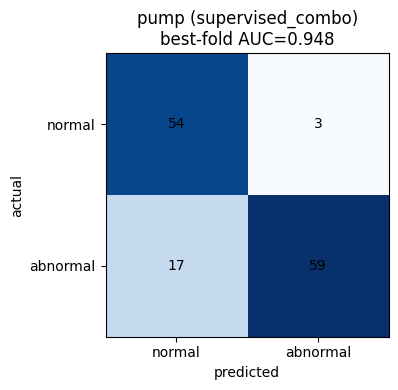

In [44]:
fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 4), squeeze=False)
for ax, (mid, r) in zip(axes[0], results.items()):
    best_arch = r["best_arch"]
    cm = np.array(r["best_fold_result"]["metrics"]["confusion_matrix"])
    ax.imshow(cm, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["normal", "abnormal"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["normal", "abnormal"])
    ax.set_xlabel("predicted"); ax.set_ylabel("actual")
    ax.set_title(f"{mid} ({best_arch})\nbest-fold AUC={r['best_fold_result']['auc']:.3f}")
plt.tight_layout()
plt.show()


In [45]:
import pickle

ARTIFACT_DIR = "artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

manifest = {"machines": {}}

for mid, info in trained_models.items():
    arch_name = info["arch"]
    art = info["artifacts"]
    best = results[mid]["best_fold_result"]
    machine_cfg = dict(PREPROC_CONFIG)
    machine_cfg["norm_mean"] = machine_configs[mid]["norm_mean"]
    machine_cfg["norm_std"] = machine_configs[mid]["norm_std"]

    # always save both component models — needed for ensemble AND supervised_combo
    weights_files = {}
    for comp_name, comp_model in art["arch_models"].items():
        wp = os.path.join(ARTIFACT_DIR, f"{mid}_{comp_name}.pt")
        torch.save(comp_model.state_dict(), wp)
        weights_files[comp_name] = os.path.basename(wp)

    entry = {
        "architecture": arch_name,
        "component_architectures": art["component_archs"],
        "weights_files": weights_files,
        "preprocessing_config": machine_cfg,
        "threshold": best["threshold"],
        "auc_roc": best["auc"],
        "metrics_at_threshold": best["metrics"],
        "cv_mean_auc": results[mid]["mean_auc_per_arch"][arch_name],
        "cv_std_auc": results[mid]["std_auc_per_arch"][arch_name],
    }

    if arch_name == "ensemble":
        entry["ensemble_norm_stats"] = art["ensemble_norm_stats"]
        entry["ensemble_combination"] = "score = 0.5*((err_v1-mean_v1)/std_v1) + 0.5*((err_v2-mean_v2)/std_v2)"
    elif arch_name == "supervised_combo":
        combiner_path = os.path.join(ARTIFACT_DIR, f"{mid}_combiner.pkl")
        with open(combiner_path, "wb") as f:
            # art["combiner_clf"] is a dict of {classifier_name: fitted_classifier}; combined via
            # AUC-weighted voting at inference using art["combiner_weights"]
            pickle.dump({
                "classifiers": art["combiner_clf"],
                "scaler": art["combiner_scaler"],
                "weights": art["combiner_weights"],
            }, f)
        entry["combiner_file"] = os.path.basename(combiner_path)
        entry["combiner_algorithm"] = art["combiner_name"]
        entry["combiner_features"] = "[mean_frame_err, max_frame_err, std_frame_err, p90_frame_err] per component model, concatenated in component_architectures order"
        entry["combiner_note"] = ("score = sum over name, classifier in classifiers.items() of "
                                   "weights[name] * classifier.predict_proba(scaler.transform(features))[:,1]")

    manifest["machines"][mid] = entry

with open(os.path.join(ARTIFACT_DIR, "manifest.json"), "w") as f:
    json.dump(manifest, f, indent=2)

cv_summary.to_csv(os.path.join(ARTIFACT_DIR, "cv_metrics_summary.csv"), index=False)

print("Artifact contents:")
for f_ in sorted(os.listdir(ARTIFACT_DIR)):
    print(" -", f_)

print("\nmanifest.json preview:")
print(json.dumps(manifest, indent=2)[:1800], "...")


Artifact contents:
 - cv_metrics_summary.csv
 - manifest.json
 - pump_combiner.pkl
 - pump_conv_ae_v1.pt
 - pump_conv_ae_v2.pt

manifest.json preview:
{
  "machines": {
    "pump": {
      "architecture": "supervised_combo",
      "component_architectures": [
        "conv_ae_v1",
        "conv_ae_v2"
      ],
      "weights_files": {
        "conv_ae_v1": "pump_conv_ae_v1.pt",
        "conv_ae_v2": "pump_conv_ae_v2.pt"
      },
      "preprocessing_config": {
        "sample_rate": 16000,
        "n_fft": 2048,
        "hop_length": 512,
        "n_mels": 128,
        "fmin": 0,
        "fmax": 8000,
        "power": 2.0,
        "top_db": 80.0,
        "fixed_frames": 313,
        "clip_duration_sec": 10.0,
        "trim_silence": true,
        "norm_mean": -29.82807159423828,
        "norm_std": 9.227758407592773
      },
      "threshold": 0.48679275703777897,
      "auc_roc": 0.9480609418282548,
      "metrics_at_threshold": {
        "precision": 0.9516129032258065,
        "reca